# «Для исследования выбран датасет Breast Cancer Wisconsin (Diagnostic). 
# Он содержит характеристики ядер клеток, извлеченных из опухолей. 
# Цель — на основе геометрических параметров предсказать диагноз: злокачественная (M) или доброкачественная (B) опухоль»

In [81]:
# ссылка на датасет: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?select=data.csv



# KDD
#импорт библиотек
import pandas as pd
import numpy as np
import sklearn
df = pd.read_csv('data.csv', low_memory = False)

df.info()

display((df.describe()))
display(df.describe(include= 'object'))
#удаляем лишнюю колонку
df = df.drop(columns= 'Unnamed: 32')
df = df.drop(columns = 'id')

display(df.head())
display(df.tail())

display(f'Колличество дубликатов: {df.duplicated().sum()}')
display(f'Колличество нулевых строк: {df.isnull().sum().sum()}')

print('\nКолличество M и B:')
display(df['diagnosis'].value_counts())

#перевод M и B в цифровые значения для распознования их роботом
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['diagnosis'] = label.fit_transform(df['diagnosis'])
display(df)

### В ходе подготовки были удалены неинформативные колонки (id, Unnamed: 32). 
### Проведена проверка на пропуски и дубликаты — данные чистые. 
### Целевая переменная закодирована (M=1, B=0). 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


,diagnosis
count,569
unique,2
top,B
freq,357


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


'Колличество дубликатов: 0'

'Колличество нулевых строк: 0'


Колличество M и B:


diagnosis
B    357
M    212
Name: count, dtype: int64

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


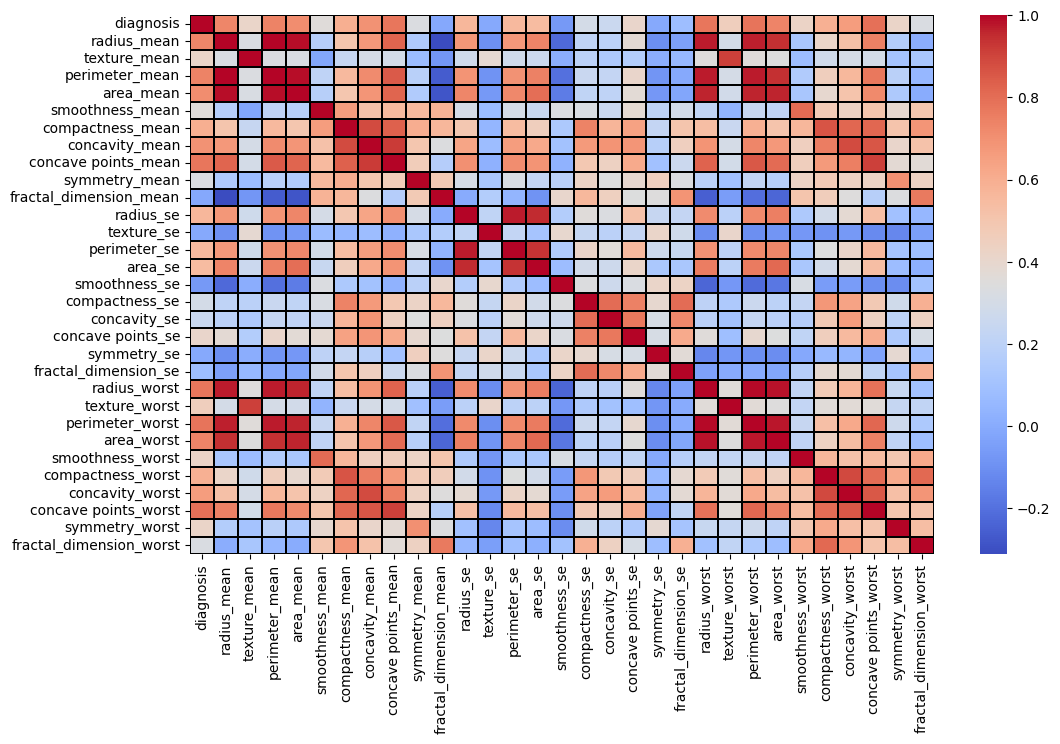

In [120]:
#Визуализация 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize= (12, 7))

corr = df[df.columns].corr()

sns.heatmap(
    data= corr,
    annot= False,
    cmap= 'coolwarm',
    linewidths= 0.1,
    linecolor='black'
)
plt.show()

#удаляем лишние колонки
df_1 = df.drop(columns= ['perimeter_mean', 'area_mean', 'radius_worst', 'perimeter_worst', 'area_worst', 'perimeter_se', 'area_se'])

### Исследование корреляций показало сильную связь между радиусом, периметром и площадью, поэтому для уменьшения размерности оставлены только значения радиуса

<Axes: xlabel='diagnosis', ylabel='symmetry_mean'>

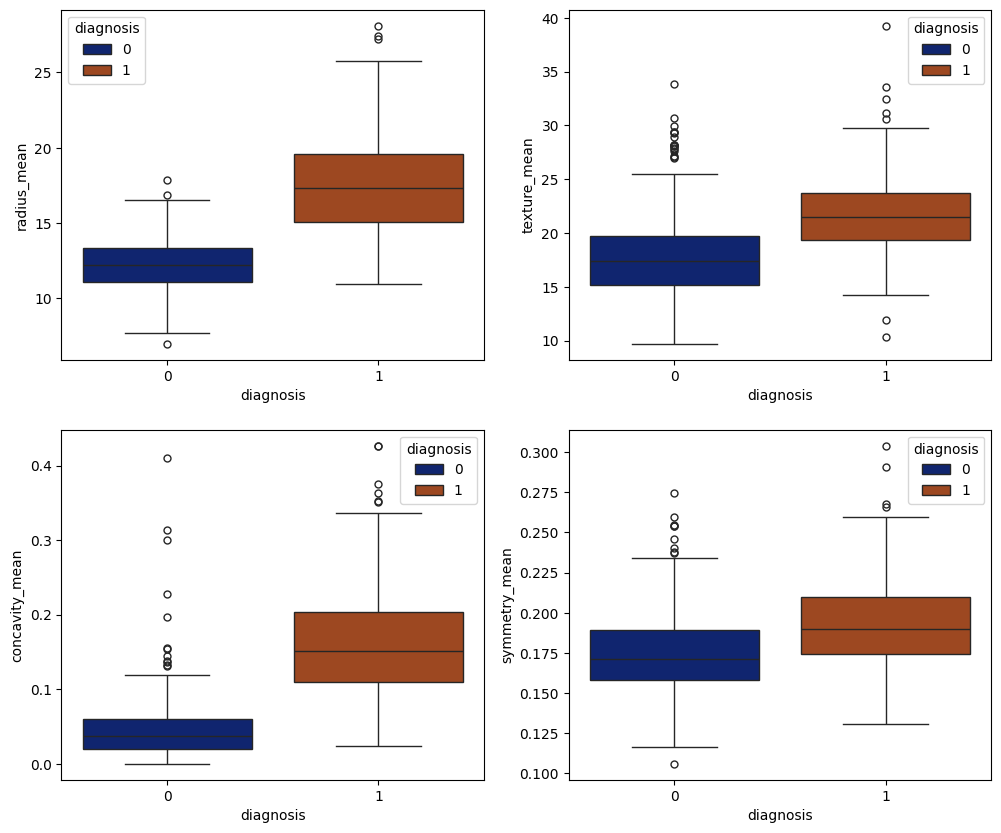

In [59]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

sns.boxplot(
    data = df_1,
    x = df_1['diagnosis'],
    y = df_1['radius_mean'],
    hue = 'diagnosis',
    palette= 'dark',
    fliersize= 5,
    ax= axes[0, 0]
)
sns.boxplot(
    data = df_1,
    x = df_1['diagnosis'],
    y = df_1['texture_mean'],
    hue = 'diagnosis',
    palette= 'dark',
    fliersize= 5,
    ax= axes[0, 1]
)
sns.boxplot(
    data = df_1,
    x = df_1['diagnosis'],
    y = df_1['concavity_mean'],
    hue = 'diagnosis',
    palette= 'dark',
    fliersize= 5,
    ax= axes[1, 0]
)
sns.boxplot(
    data = df_1,
    x = df_1['diagnosis'],
    y = df_1['symmetry_mean'],
    hue = 'diagnosis',
    palette= 'dark',
    fliersize= 5,
    ax= axes[1, 1]
)

In [71]:
#### Метод KNN считает «близость» объектов, вычисляя расстояние между ними (например Евклидово расстояние) 
# и у нас допустим есть два признака: 
#   radius_mean: значения от 10 до 30.
#   concavity_mean: значения от 0.01 до 0.4.
# получается, что если не масштабировать данные, то разница в 1 единицу по радиусу будет вносить в формулу расстояния вклад в 100 раз больший, чем вся разница по вогнутости (которая даже до 1 не доходит)

###  нельзя подбирать параметры на тестовой выборке, так как модель будет 'подглядывать' в тест и подстраиваться именно к нему.
# Следовательно модель будет решать конкретно тот тест на отлично, но как только дойдет до настоящей практики, то точность модели будет минимальной


# отбираем таблицу с данными и с ответами
test_cancer = df_1.drop(columns = ['diagnosis'])
true_cancer = df_1['diagnosis']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    test_cancer, true_cancer, test_size= 0.2, random_state= 42)

# масштабирование данных
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform= 'pandas')

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


### Данные разделены на обучающую и тестовую выборки в пропорции 80/20. 
### Так как KNN основан на расчете Евклидова расстояния, было проведено масштабирование признаков с помощью StandardScaler. 
### Без этого признаки с большими значениями (например, площадь) доминировали бы над остальными

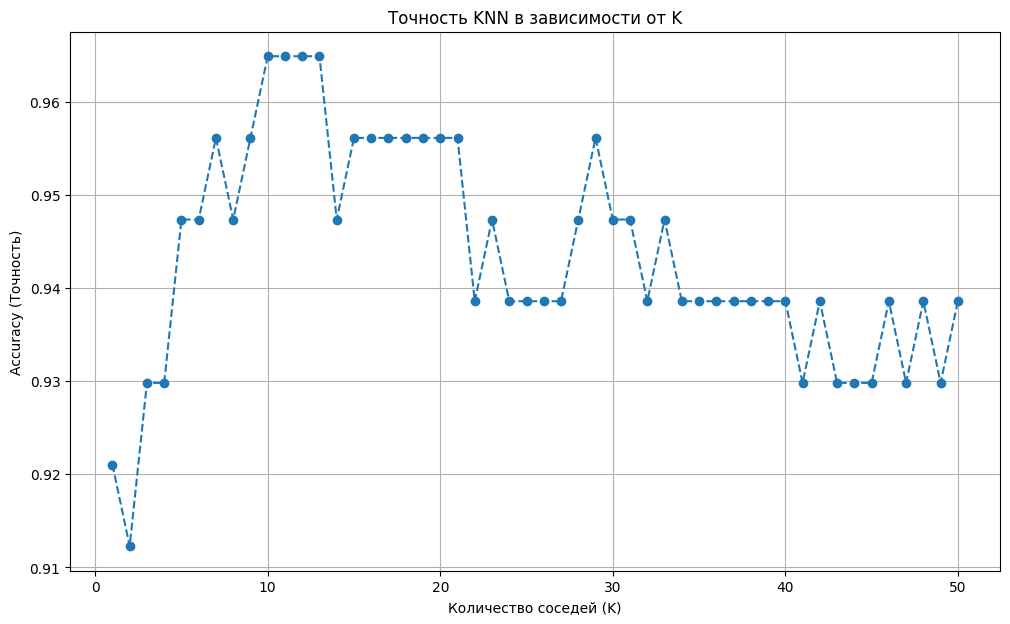

In [80]:
### Подбор наилучшенго K для KNN-метода
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#создаем пустой список и диапазон значений K
scores = []
k = range(1, 51)
for i in k:
    model = KNeighborsClassifier(n_neighbors= i) #создаем модель
    
    model.fit(x_train_scaled, y_train) #запуск обучения
    
    predictions = model.predict(x_test_scaled) #даем модели предсказать результы на тестовых данных

    acc = accuracy_score(y_test, predictions) #точность предсказаний

    scores.append(acc)

#строим график для того, чтобы понять, какой K выдает наибольшую точность
plt.figure(figsize=(12, 7))

plt.plot(
    k,
    scores,
    marker = 'o',
    linestyle = '--'
)
plt.title('Точность KNN в зависимости от K')
plt.xlabel('Количество соседей (K)')
plt.ylabel('Accuracy (Точность)')

plt.grid(True)
plt.show()


###Первичное исследование показало, что при ручном подборе оптимальное количество соседей находится в диапазоне 10–13. 

In [91]:
### Сравнение типов весов и различных метрик

# создаем словарь конфигураций, которые мы используем
dict1 = [
    {'n_neighbors': 11, 'weights': 'uniform', 'metric': 'euclidean'},
    {'n_neighbors': 11, 'weights': 'distance', 'metric': 'euclidean'},
    {'n_neighbors': 11, 'weights': 'uniform', 'metric': 'manhattan'},
    {'n_neighbors': 11, 'weights': 'distance', 'metric': 'manhattan'}
]

print(f"{'Метрика':<12} | {'Веса':<10} | {'Точность':<10}")
print('-' * 45)

for i in dict1:
    model = KNeighborsClassifier(**i)
    model.fit(x_train_scaled, y_train)
    pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_test, pred)

    print(f"{i['metric']:<12} | {i['weights']:<10} | {acc:.4f}")


### При всех параметрах метрик и весов получилось везде одинаковая точность, что указывает на хорошую разделимость классов. 
### А неугаданные точки действительно имеют сложные пограничные случаи

Метрика      | Веса       | Точность  
---------------------------------------------
euclidean    | uniform    | 0.9649
euclidean    | distance   | 0.9649
manhattan    | uniform    | 0.9649
manhattan    | distance   | 0.9649


In [100]:
### Кросс-валидация
from sklearn.model_selection import GridSearchCV

dict_grid = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

model = KNeighborsClassifier()

grid_search = GridSearchCV(model, dict_grid, cv= 5, scoring= 'accuracy')  # cv=5 означает, что данные будут биться на 5 частей

grid_search.fit(x_train_scaled, y_train)

print(f'Лучшие параметры: {grid_search.best_params_}')
print("Лучшая точность на кросс-валидации:", grid_search.best_score_)


# проверим без масштабирования какая будет точность
grid_search_ = GridSearchCV(model, dict_grid, cv= 5, scoring= 'accuracy')
grid_search_.fit(x_train, y_train)

print(f'\nЛучшие параметры: {grid_search_.best_params_}')
print("Лучшая точность на кросс-валидации без масштабирования:", grid_search_.best_score_)

## Для получения более надежных результатов применен поиск по сетке с кросс-валидацией (5 фолдов). 
## Это позволило избежать переобучения под конкретную тестовую выборку

###Выводы
# С масштабированием: точность ~95.8% Без масштабирования: точность ~92.7%
# На отмасштабированных данных победила Euclidean (классика). На неотмасштабированных данных победила Manhattan.
##Кросс-валидация выбрала 20 соседей. Это больше, чем те 10, которые мы видели на одном случайном разбиении. 
 #Вывод: Большее количество соседей дает более «гладкую» границу и лучше защищает модель от случайного шума в данных.


Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'distance'}
Лучшая точность на кросс-валидации: 0.9582417582417582

Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}
Лучшая точность на кросс-валидации без масштабирования: 0.9274725274725275


In [105]:
# отберем лучшую модель
best_model = grid_search.best_estimator_

pred_1 = best_model.predict(x_test_scaled)
acc_1 = accuracy_score(pred_1, y_test)
print(f'Итоговая точность: {acc_1:.4f}')

### Итог: «Модель KNN показала высокую эффективность на данном датасете (точность ~96%), однако требует тщательной предобработки данных (scaling)

Итоговая точность: 0.9561


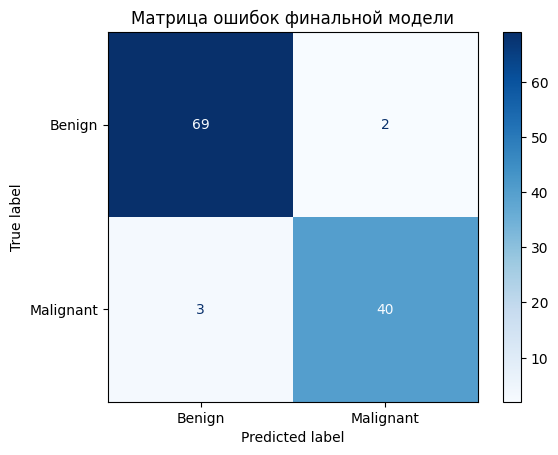

In [118]:
#### Матрица ошибок
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred_1)

disp = ConfusionMatrixDisplay(
    confusion_matrix= cm,
    display_labels=['Benign', 'Malignant']
)

disp.plot(cmap=  'Blues')
plt.title('Матрица ошибок финальной модели')
plt.show()